**Created by Justin Cooke on April 27th, 2026**

Purpose of this script is to calculate a GEM in the region of the LC from the HYCOM data to investigate why do the larger scales that exist in the model result in higher variance.

We hope to find what's the depth of the strongest $N^2$ across the jet and what is that value?

In [1]:
# Import modules

import warnings
warnings.filterwarnings('ignore')

# Sci computing
import numpy as np
import scipy as sp
import seawater as sw
import scipy.sparse.linalg as sla

# Parallel comupting
from dask.distributed import Client, LocalCluster
from dask.diagnostics import ProgressBar

# For Data
import netCDF4 as nc
import xarray as xr

# Plotting stuff
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as grdspc
import cmocean as cm

# Importing bathymetry (tiff)
import rasterio as geo

# Gen stuff
from datetime import date
today = date.today()
import glob

In [2]:
# First we need to define a function dpth which is converts pressure to depth in m

def dpth(pres_dbar,lat_deg):
    x = np.sin(np.radians(lat_deg))**2
    g = 9.780318 * (1.0 + (5.2788e-3 + 2.36e-5 * x) * x)

    depth_in_m = (((-1.82e-15 * pres_dbar + 2.279e-10) * pres_dbar - 2.2512e-5) * pres_dbar + 9.72659) * pres_dbar / g

    return depth_in_m

def prs(depth_meters, latitude_deg, tol=0.001):
    # Iteratively compute pressure [dbar] from depth [m] and latitude [deg] 

    # Parameters
    # depth_meters : float or np.ndarray
        # Depth in meters
    # latitude_deg : float or np.ndarray
        # Latitude degrees north (-90 to 90)
    # tol          : float, optional

    # Returns
    # pressure : np.ndarray 
        # Pressure in decibar (dbar)
    # iterations : int
        # Number of iterations used to converge

    # Convert inputs to arrays

    depth_meters = np.atleast_1d(depth_meters).astype(float)
    latitude_deg = np.atleast_1d(latitude_deg).astype(float)

    # Broadcast latitude to depth shape if needed
    if latitude_deg.size == 1:
        latitude_deg = np.full_like(depth_meters,latitude_deg)
    elif latitude_deg.shape != depth_meters.shape:
        if latitude_deg.shape[0] == depth_meters.shape[1]:
            latitude_deg = np.tile(latitude_deg, (depth_meters.shape[0],1))
        else: 
            raise ValueError("Latitude and Depth must have compatible dimensions")
        
    # Initialization
    pressure = 1.01 * depth_meters
    converged = False
    max_iters = 20
    iters = 1

    while not converged and iters <= max_iters:
        d = dpth(pressure,latitude_deg)
        new_pressure = pressure + (depth_meters - d) * 1.01
        delta = np.abs(new_pressure - pressure)

        if np.max(delta) < tol:
            converged = True

        pressure = new_pressure
        iters += 1

    if not converged:
        pressure[:] = np.nan

    return pressure.squeeze()

In [3]:
# For plotting; have the bathymetry of the gulf

ds_gulf = geo.open('/home/justin_cooke_uri_edu/DeepCyclones/gulf.tiff')
#ds_gulf = geo.open('../gulf.tiff')
img = ds_gulf.read(1)

(gm,gn) = np.shape(img)
gulf_lon = np.linspace(-90,-82,gn)
gulf_lat = np.linspace(22,28,gm)

# To get the aspect ratio right
ymid = np.mean(gulf_lat)
ymid_rad = ymid*np.pi/180

# For plotting: labels

lon_xticks = np.array((-90,-89,-88,-87,-86,-85,-84,-83))
lon_xticklbls = ['$90^\circ$W','$89^\circ$W','$88^\circ$W','$87^\circ$W','$86^\circ$W','$85^\circ$W','$84^\circ$W','$83^\circ$W']

lat_yticks = np.array((22,23,24,25,26,27,28))
lat_yticklbls = ['$22^\circ$N','$23^\circ$N','$24^\circ$N','$25^\circ$N','$26^\circ$N','$27^\circ$N','$28^\circ$N']

In [3]:
# Load Variables

ds_depth = nc.Dataset('./hycom_data/hycom_depth.nc')
z = ds_depth['Depth'][:]
ind2k = list(np.where(z >= 3000))[0][0]
depth = z[:ind2k+1]

ds_theta = nc.Dataset('./hycom_data/hycom_temp_slice86W_fullZ.nc')
theta = np.squeeze(ds_theta['temperature'][:,:ind2k+1,:,:])

ds_sal = nc.Dataset('./hycom_data/hycom_sal_slice86W_fullZ.nc')
sal = np.squeeze(ds_sal['salinity'][:,:ind2k+1,:,:])

ds_latslice = nc.Dataset('./hycom_data/hycom_lat_slice86W_fullZ.nc')
lat = ds_latslice['Latitude'][:]
lon = ds_latslice['Longitude'][:]

# Lengths of interest

Nt,Nz,Nlat = theta.shape

In [4]:
# Mask locations which do not reach the full depth of the water column (2000 meters depth)

# Finds the columns which have a mask applied at any depth
mask_col = np.any(sal.mask,axis=1)
# Create a new mask with dimensions time x depth x lat
full_mask = mask_col[:,np.newaxis,:]
# Combine the new mask with the existing mask 
new_mask = sal.mask | full_mask
# Create new masked array for each variable
sal_masked   = np.ma.array(sal.data,mask=new_mask)
theta_masked = np.ma.array(theta.data,mask=new_mask)

In [5]:
# Converting depth to pressure (dbar)

# Need to create an mxn array where m = [depth] and n = [latitude] to be used in prs
DPTH, LAT = np.meshgrid(depth,lat)

# Get pressure -- output is lat x depth (annoying)
pressure = prs(DPTH,LAT)
# Add new axis for time
p_full = pressure[np.newaxis,:,:]
# Fill for all time pressure array
p_full = np.tile(p_full,(Nt,1,1))
# Swap depth and lat so we have p_full with time x depth x lat
p_full = np.moveaxis(p_full,[0,1,2],[0,2,1])
# mask like temp and salinity
p_full_masked = np.ma.array(p_full.data,mask=new_mask)
# create a reference pressure array
pref = np.ma.zeros_like(p_full_masked)

In [6]:
# Now we can handle converting potential temp to temp

temp_masked = sw.eos80.temp(sal_masked,theta_masked,p_full_masked,pref)

In [7]:
# What days to do:

from contourpy import contour_generator

ds_ssh     = xr.load_dataset('./hycom_data/hycom_ssh_filtered.nc') # SSH

ssh        = ds_ssh['ssh'] # SSH
ssh_demean = ssh - xr.DataArray.mean(ssh,dim=["Latitude","Longitude"],skipna=True) # SSH demeaned -- remove the daily spatial mean from SSH

lon_ssh = ssh_demean['Longitude'] # Longitdue
lat_ssh = ssh_demean['Latitude'] # Latitdue

Nt_ssh,_,_ = ssh_demean.shape # Grab the dimensions of the ssh array

# For our dataseat, calculate LC Characteristics
 
RadEarth = 6371  # [km]

LC = {
    'length': np.zeros(Nt_ssh),
    'west': np.zeros(Nt_ssh),
    'north': np.zeros(Nt_ssh)
}

for j in range(Nt_ssh):

    z_field = ssh_demean.isel(MT=j)

    # Create a ContourGenerator instance once (x, y are 1D coordinate arrays)
    contour_gen = contour_generator(
        x=lon_ssh, y=lat_ssh, z=z_field,  # z will be passed per iteration
        line_type="Separate"          # ensures each contour is a separate array
    )


    # Generate contours for the j-th SSH slice at level 0.17
    contour_segments = contour_gen.lines(0.17)  # list of Nx2 arrays (x, y)

    curveLength = np.zeros(len(contour_segments))
    curveWest = np.zeros(len(contour_segments))
    curveNorth = np.zeros(len(contour_segments))

    for k, seg in enumerate(contour_segments):
        myX = seg[:,0]
        myY = seg[:,1]

        YCheck = myY <= 22.1
        XCheck = myX >= -86.5

        if (-83 in myX) or (np.any(YCheck) and np.any(XCheck)):
            idx_candidates = np.where(myY >= 23)[0]
            idx_w = idx_candidates[-1] if len(idx_candidates) > 0 else None

            curveNorth[k] = np.max(myY)

            if idx_w is None or np.abs(myY[idx_w]) >= 89.9:
                curveWest[k] = 0
            else:
                curveWest[k] = myX[idx_w]

            # Compute great-circle distance along the contour
            this_curve = 0.0
            for i in range(len(myX) - 1):
                lam_1 = np.deg2rad(myX[i])
                lam_2 = np.deg2rad(myX[i + 1])
                phi_1 = np.deg2rad(myY[i])
                phi_2 = np.deg2rad(myY[i + 1])

                delphi = phi_2 - phi_1
                dellam = lam_2 - lam_1

                thisDist = 2 * RadEarth * np.asin( np.sqrt(( 1 - np.cos((delphi)) +
                                                  ((np.cos(phi_1)) * np.cos(phi_2) * 
                                                   (1 - np.cos(dellam) ) )) / 2)) 

                this_curve += thisDist

            curveLength[k] = this_curve

    LC['west'][j] = np.max(np.abs(curveWest)) if len(curveWest) > 0 else 0 # Westward extension of LC 
    LC['north'][j] = np.max(np.abs(curveNorth)) if len(curveNorth) > 0 else 0 # Northern extension of LC
    LC['length'][j] = np.sum(curveLength) if len(curveLength) > 0 else 0 # LC Length



In [8]:
from scipy.signal import find_peaks

lc_length_peaks, _ = find_peaks(LC['length'],height=(np.mean(LC['length'])+np.std(LC['length'])))

In [9]:
# Now calculate buoyancy frequency

# Days where LC is extended
t_ext = lc_length_peaks #np.array([485,490,495,910,915,920,1390,1400,1410,2705,4370,4375,4380,4385,4390,4740,4745,4780,5570,5575,5580])
Nt_ext = len(t_ext)

# Preallocate for N^2
n2 = np.ma.empty((Nt_ext,Nz-1,Nlat))

for n in range(Nt_ext):
    sal_slice = sal_masked[n,:,:]
    temp_slice = temp_masked[n,:,:]
    p_slice = p_full_masked[n,:,:]
    bfreq, q, p_ave = sw.bfrq(sal_slice,temp_slice,p_slice,lat)
    n2[n,:,:] = bfreq

# ext mask
ext_mask = new_mask[t_ext,:-1,:]
n2_masked = np.ma.array(data=n2,mask=ext_mask)

# Calculate mid point between adjacent pressures 
p_mid = (p_full_masked[0,:-1,:] + p_full_masked[0,1:, :]) / 2
p_mid_plot = p_mid[:,20]

In [10]:
# Need to calculate geopotential anomaly
# First we need to calculate the specific volume anomaly

# Density and Ref Density

# Reference T/S
s35 = np.ma.ones((Nt_ext,Nz-1,Nlat)) * 35
s35_masked = np.ma.array(data=s35,mask=ext_mask)
t0 = np.ma.zeros((Nt_ext,Nz-1,Nlat))
t0_masked = np.ma.array(data=t0,mask=ext_mask)
p_mid_full = p_mid[np.newaxis,:,:]
p_mid_full = np.tile(p_mid_full,(Nt_ext,1,1))

dens_350p = sw.eos80.dens(s35, t0, p_mid_full)
sv_350p = 1.0 / dens_350p

# Density
dens_stp = sw.eos80.dens(sal_masked[t_ext,:-1,:], temp_masked[t_ext,:-1,:], p_mid_full)  # broadcasts over time
sv_stp = 1.0 / dens_stp

# SVAN
svan = sv_stp - sv_350p

# Convert pressure from dbar to Pascals
p_Pa = p_mid_full * 1e4  

gpan = np.ma.empty((Nt_ext,Nlat))

for n in range(Nt_ext):

    this_svan   = svan[n,7:-9,:]
    this_p      = p_Pa[n,7:-9,:]
    #this_svan   = svan[n,7:,:]
    #this_p      = p_Pa[n,7:,:]
    
    # Integrate svan from 150 to 2000 m 
    tempp = sp.integrate.trapezoid(this_svan, this_p, axis=0)
    gpan[n,:] = tempp

In [11]:
mask_all = gpan.mask.all(axis=0)
gpan_good = gpan[:, ~mask_all].flatten() #gpan[:,17:-2].flatten()
gpan_sort_idx = np.argsort(gpan_good)
gpan_good_sorted = gpan_good[gpan_sort_idx]

myMask = np.ma.getmaskarray(n2_masked)
mask_all_depth = myMask.all(axis=1)
mask_any_time = mask_all_depth.any(axis=0)
n2_masked_good = n2_masked[:,:,~mask_any_time]

n2_flat = n2_masked_good.transpose(1,0,2).reshape(n2_masked_good.shape[1],-1)
gpan_sort_idx_full = gpan_sort_idx[np.newaxis,:]
gpan_sort_idx_full = np.tile(gpan_sort_idx_full,[Nz-1,1])
n2_flat_sorted = np.take_along_axis(n2_flat,gpan_sort_idx_full,axis=-1)

myTemp = temp_masked[t_ext,:-1,:]
temp_masked_good = myTemp[:,:,~mask_any_time]

temp_flat = temp_masked_good.transpose(1,0,2).reshape(temp_masked_good.shape[1],-1)
temp_flat.shape

temp_flat_sorted = np.take_along_axis(temp_flat,gpan_sort_idx_full,axis=-1)

mySal = sal_masked[t_ext,:-1,:]
sal_masked_good = mySal[:,:,~mask_any_time]

sal_flat = sal_masked_good.transpose(1,0,2).reshape(sal_masked_good.shape[1],-1)
sal_flat.shape

sal_flat_sorted = np.take_along_axis(sal_flat,gpan_sort_idx_full,axis=-1)

print('Phi min: ',np.nanmin(gpan_good_sorted), '\nPhi max: ',np.nanmax(gpan_good_sorted))

Phi min:  6.560554756037171 
Phi max:  15.840400979742265


5115


Text(0.5, 0, 'N^2')

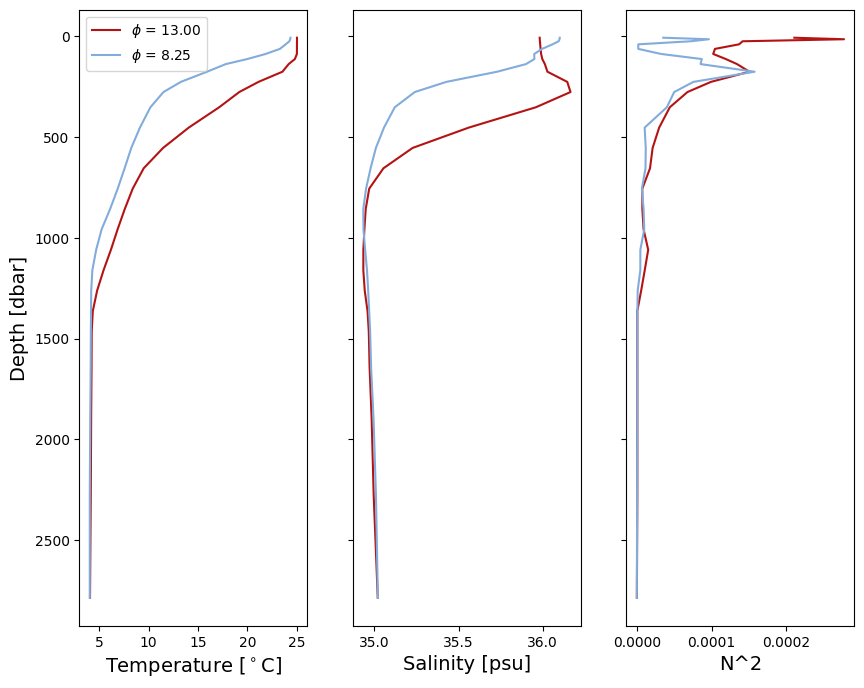

In [12]:
# Want to find a cold and hot phi -- 8.25 and 13
# Next, use the current index in gpan_good_sorted to find the original indices of the two profiles
# Then get T, S, and N^2 at those points, plotting them

hot_idx  = np.where(gpan_good_sorted >= 13)[0][0]
cold_idx = np.where(gpan_good_sorted >= 8.25)[0][0]

orig_hot_idx  = gpan_sort_idx[hot_idx]
orig_cold_idx = gpan_sort_idx[cold_idx]

print(orig_hot_idx)
fig = plt.subplots(1,3,figsize=(10,8))
ax = plt.subplot(1,3,1)
ax.plot(temp_flat[:,orig_hot_idx],p_mid_plot,label=f'$\phi$ = {gpan_good_sorted[hot_idx]:.2f}',color="#b41313")
ax.plot(temp_flat[:,orig_cold_idx],p_mid_plot,label=f'$\phi$ = {gpan_good_sorted[cold_idx]:.2f}',color="#82acdb")
ax.invert_yaxis()
ax.legend()
ax.set_ylabel('Depth [dbar]',fontsize=14)
ax.set_xlabel('Temperature [$^\circ$C]',fontsize=14)
#ax.set_title('Temperature',fontsize=16)

ax = plt.subplot(1,3,2)
ax.plot(sal_flat[:,orig_hot_idx],p_mid_plot,label=f'$\phi$ = {gpan_good_sorted[hot_idx]:.2f}',color="#b41313")
ax.plot(sal_flat[:,orig_cold_idx],p_mid_plot,label=f'$\phi$ = {gpan_good_sorted[cold_idx]:.2f}',color='#82acdb')
ax.invert_yaxis()
ax.set_yticklabels([''])
#ax.set_title('Salinity',fontsize=16)
ax.set_xlabel('Salinity [psu]',fontsize=14)

ax = plt.subplot(1,3,3)
ax.plot(n2_flat[:,orig_hot_idx],p_mid_plot,label=f'$\phi$ = {gpan_good_sorted[hot_idx]:.2f}',color="#b41313")
ax.plot(n2_flat[:,orig_cold_idx],p_mid_plot,label=f'$\phi$ = {gpan_good_sorted[cold_idx]:.2f}',color='#82acdb')
ax.invert_yaxis()
ax.set_yticklabels([''])
#ax.set_title('Salinity',fontsize=16)
ax.set_xlabel('N^2',fontsize=14)


In [54]:
# Save hot and cold phi profiles for Randy

from scipy.io import savemat

hot_temp_prof  = temp_flat[:,orig_hot_idx]
cold_temp_prof = temp_flat[:,orig_cold_idx]

hot_sal_prof  = sal_flat[:,orig_hot_idx]
cold_sal_prof = sal_flat[:,orig_cold_idx]

p_mid_forProfs = p_mid_plot

savemat('./data/HotCold_TandS_fromHYCOM.mat',{'T_hot': hot_temp_prof, 'T_cold': cold_temp_prof, 'S_hot': hot_sal_prof, 'S_cold': cold_sal_prof, 'P_dbar': p_mid_forProfs})

In [16]:
from scipy.stats import binned_statistic

n_depth = Nz-1
n_bins = 20

# Global bin edges based on sorted geopotential anomaly
bin_edges = np.linspace(np.nanmin(gpan_good_sorted), np.nanmax(gpan_good_sorted), num=n_bins + 1)
#bin_edges = np.linspace(5.835,13.5005,num=n_bins+1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# Output array: [n_depth, n_bins]
n2_bin_means = np.full((n_depth, n_bins), np.nan)
temp_bin_means = np.full((n_depth,n_bins),np.nan)
sal_bin_means = np.full((n_depth,n_bins),np.nan)

for k in range(n_depth):
    n2_bin_means[k, :], _, _ = binned_statistic(
        gpan_good_sorted,
        n2_flat_sorted[k, :],
        statistic='mean',
        bins=bin_edges
    )
    temp_bin_means[k,:],_,_ = binned_statistic(
        gpan_good_sorted,
        temp_flat_sorted[k,:],
        statistic='mean',
        bins=bin_edges
    )
    sal_bin_means[k,:],_,_ = binned_statistic(
        gpan_good_sorted,
        sal_flat_sorted[k,:],
        statistic='mean',
        bins=bin_edges
    )

hot_phi = np.where(bin_centers >= 13.2)[0][0]
cold_phi = np.where(bin_centers >= 8.)[0][0]

print(f'Hot Phi: {bin_centers[hot_phi]:.2f}\nCold Phi: {bin_centers[cold_phi]:.2f}')

Hot Phi: 13.29
Cold Phi: 8.18


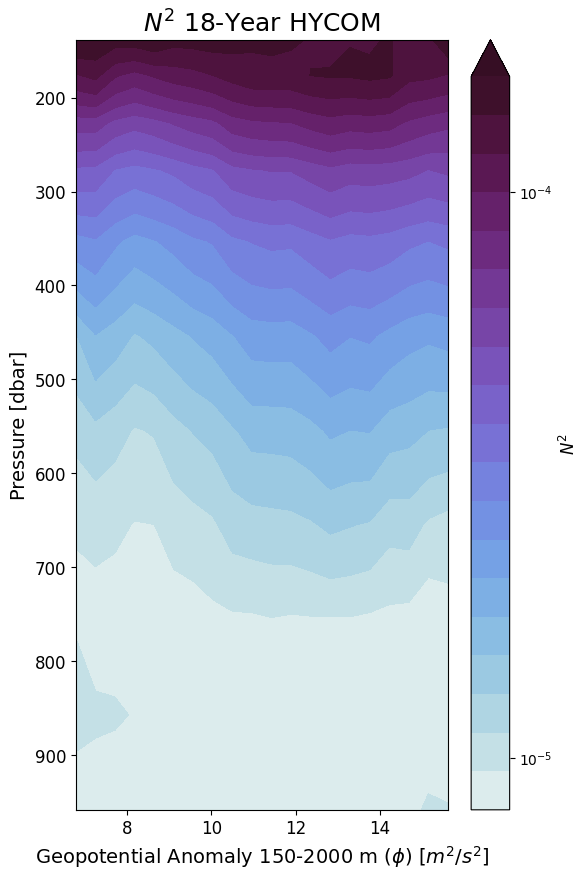

In [17]:
from matplotlib.ticker import LogLocator,LogFormatterSciNotation

n2_plot = n2_bin_means[7:-9,:]
#n2_plot = n2_bin_means[7:,:]
n2_plot_min = np.nanmin(n2_plot)
n2_plot_max = np.nanmax(n2_plot)

log_lvl=np.logspace(np.log10(n2_plot_min),np.log10(n2_plot_max),20)

fig,ax = plt.subplots(figsize=(6,10))
cb = ax.contourf(bin_centers,p_mid_plot[7:-9],n2_plot,levels=log_lvl,norm=mpl.colors.LogNorm(vmin=n2_plot_min, vmax=n2_plot_max),cmap=cm.cm.dense,extend='max')
#cb = ax.contourf(bin_centers,p_mid_plot[7:],n2_plot,levels=log_lvl,norm=mpl.colors.LogNorm(vmin=n2_plot_min, vmax=n2_plot_max),cmap=cm.cm.dense,extend='max')
ax.invert_yaxis()
cbar = fig.colorbar(cb,ax=ax)
cbar.set_label('$N^2$',size=12)
cbar.ax.yaxis.set_major_locator(LogLocator(base=10.0,numticks=10))
ax.set_title('$N^2$ 18-Year HYCOM',fontsize=18)
ax.set_ylabel('Pressure [dbar]',fontsize=14)
ax.set_xlabel('Geopotential Anomaly 150-2000 m ($\phi$) [$m^2/s^2$]',fontsize=14)

ax.tick_params(axis='both',which='major',labelsize=12)

#plt.savefig(f'./Figures/CPIES_Var/BuoyancyFreq_HYCOM_{today}.svg',format='svg')

In [ ]:
fig,ax = plt.subplots(figsize=(6,10))

ax.plot(n2_bin_means[:,4],p_mid_plot,label=f'$\phi = ${bin_centers[4]:.1f}',linewidth=2)
ax.plot(n2_bin_means[:,-4],p_mid_plot,label=f'$\phi = ${bin_centers[-4]:.1f}',linewidth=2)
ax.invert_yaxis()
#ax.set_ylim(1000,100)
ax.tick_params(axis='both',which='major',labelsize=12)
ax.set_ylabel('Pressure [dbar]',fontsize=18)
ax.set_xlabel('$N^2$ [$1/s^2$]',fontsize=18)
ax.ticklabel_format(style='sci',axis='x',scilimits=(0,0))
ax.set_title('$N^2$ Profiles 18-Year HYCOM',fontsize=20)
plt.legend()

#fig.savefig(f'./Figures/CPIES_Var/N2_profiles_{today}.svg',format='svg')

In [ ]:
temp_plot = temp_bin_means[7:-6,:]

fig,ax = plt.subplots(figsize=(6,10))

ax.plot(temp_bin_means[:,4],p_mid_plot,label=f'$\phi = ${bin_centers[4]:.1f}',linewidth=2)
ax.plot(temp_bin_means[:,-4],p_mid_plot,label=f'$\phi = ${bin_centers[-4]:.1f}',linewidth=2)
ax.invert_yaxis()
ax.tick_params(axis='both',which='major',labelsize=12)
ax.set_ylabel('Pressure [dbar]',fontsize=18)
ax.set_xlabel('Temperature [$^\circ$C]',fontsize=18)
#ax.set_ylim(1000,100)
#ax.ticklabel_format(style='sci',axis='x',scilimits=(0,0))
ax.set_title('Temp Profiles 18-Year HYCOM',fontsize=20)
plt.legend()

#ig.savefig(f'./Figures/CPIES_Var/N2_profiles_{today}.svg',format='svg')

In [18]:
# GEM Data from UGOS

from scipy.io import loadmat

ds_gem = loadmat('./data/GEM_deseasonedtauTmp.mat')

gem_lat  = ds_gem['GEM']['lat'][0][0][0][:]
gem_temp = ds_gem['GEM']['tmp'][0][0][:]
gem_sal  = ds_gem['GEM']['sal'][0][0][:]
gem_prs  = ds_gem['GEM']['Pressure'][0][0][:]

# Mask the arrays
gem_temp = np.ma.masked_invalid(gem_temp)
gem_sal  = np.ma.masked_invalid(gem_sal)
gem_prs = gem_prs
print(f'Pressure shape: {gem_prs.shape}\nSalinity shape: {gem_sal.shape}')

# Calculate N2, pot. vort., and average pressures
gem_n2, gem_q, gem_pmid = sw.geostrophic.bfrq(gem_sal,gem_temp,gem_prs)
print(f'     N^2 shape: {gem_n2.shape}')

Pressure shape: (352, 1)
Salinity shape: (352, 4426)
     N^2 shape: (351, 4426)


In [20]:
# Calculate Geopotential Anamoly

# Reference salinity and temperature are 35 psu and 0C, respectively
gem_s35 = np.full_like(gem_sal,35.0)
gem_t0  = np.zeros_like(gem_temp)

# Meshgrid to get pressure in the correct form
GLAT,GPRES = np.meshgrid(gem_lat,gem_prs)

# Density and then specific volume
gem_dens_350p = sw.eos80.dens(gem_s35,gem_t0,GPRES)
gem_dens_stp  = sw.eos80.dens(gem_sal,gem_temp,GPRES)

gem_sv_350p = 1 / gem_dens_350p
gem_sv_stp  = 1 / gem_dens_stp 

# SVAN
gem_svan = gem_sv_stp - gem_sv_350p

# Find indices for 150 dbar and 1000 dbar
idx150 = np.where(gem_prs >= 150)[0][0]
idx1000 = np.where(gem_prs >= 1000)[0][0]

# Convert pressure from dbar to Pascals
gem_p_Pa = np.squeeze(gem_prs[idx150:idx1000+1] * 1e4)  
Nglat = len(gem_lat)

gem_gpan = np.ma.empty(Nglat)

for n in range(Nglat):

    this_svan   = gem_svan[idx150:idx1000+1,n]
        
    # Integrate svan from 150 to 2000 m 
    toss_me = sp.integrate.trapezoid(this_svan, gem_p_Pa, axis=0)
    gem_gpan[n] = toss_me

print(f'Phi Shape: {gem_gpan.shape}\nPhi Range:\nPhi Max = {np.nanmax(gem_gpan):.2f} Phi Min = {np.nanmin(gem_gpan):.2f}')

Phi Shape: (4426,)
Phi Range:
Phi Max = 13.51 Phi Min = 4.12


In [24]:
# Sort gpan 

gem_gpan_sort_idx = np.argsort(gem_gpan)
gem_gpan_sorted = gem_gpan[gem_gpan_sort_idx]
gem_gpan_idx_full = gem_gpan_sort_idx[np.newaxis,:]
gem_gpan_idx_full = np.tile(gem_gpan_sort_idx,[len(gem_pmid),1])
gem_n2_sorted = np.take_along_axis(gem_n2,gem_gpan_idx_full,axis=-1)
gem_temp_sorted = np.take_along_axis(gem_temp[:-1,:],gem_gpan_idx_full,axis=-1)
gem_sal_sorted = np.take_along_axis(gem_sal[:-1,:],gem_gpan_idx_full,axis=-1)

In [45]:
gem_temp.data[:,gem_hot_idx]

array([28.95988526, 28.94006398, 28.79981452, 28.23856953, 25.16022179,
       24.0685018 , 23.53719318, 22.56107449, 22.07006264, 21.31401905,
       20.96339652, 20.57442691, 20.04130612, 19.25015708, 18.89076486,
       18.59615502, 18.22449969, 17.57480029, 16.78009078, 16.28300095,
       15.55200005, 15.16707629, 14.66344427, 14.35577767, 14.05799961,
       13.47799969, 13.23457171, 12.98861276, 12.7987603 , 12.5325    ,
       12.23774471, 11.94138461, 11.60340451, 11.39003809, 11.06644257,
       10.88872323, 10.7334901 , 10.46909789, 10.25900031, 10.05684607,
        9.91197933,  9.79063995,  9.64820027,  9.48910615,  9.36178852,
        9.21500004,  9.0456668 ,  8.90078238,  8.76139581,  8.68008009,
        8.61309339,  8.55133324,  8.48057398,  8.3815554 ,  8.27812859,
        8.19353475,  8.12481661,  8.05813269,  7.96113888,  7.84806968,
        7.74391087,  7.64229861,  7.51455876,  7.40229607,  7.30452997,
        7.20639775,  7.1138997 ,  7.01017954,  6.90585143,  6.81

Text(0.5, 0, 'Salinity [psu]')

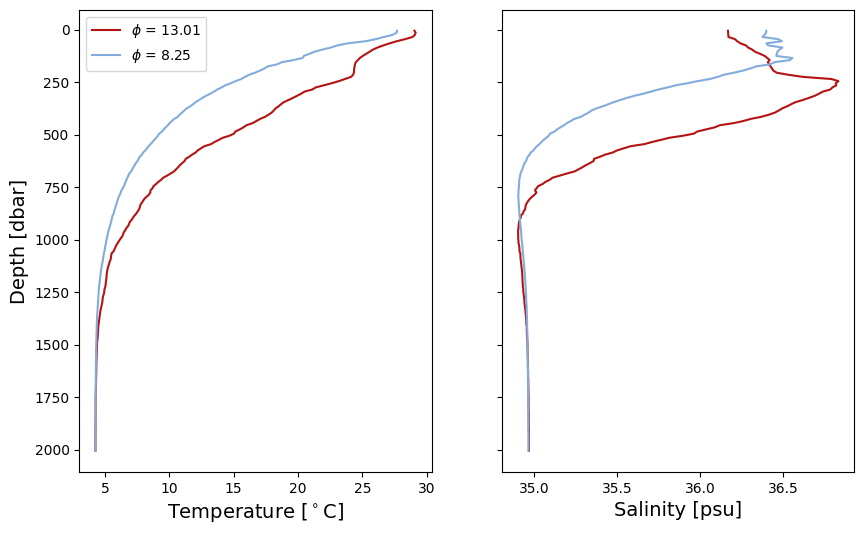

In [58]:
# Want to find a cold and hot phi -- 8.25 and 13
# Next, use the current index in gpan_good_sorted to find the original indices of the two profiles
# Then get T, S, and N^2 at those points, plotting them

gem_hot_idx  = np.where(gem_gpan_sorted >= 13)[0][1]
gem_cold_idx = np.where(gem_gpan_sorted >= 8.25)[0][0]

orig_gem_hot_idx  = gem_gpan_sort_idx[gem_hot_idx]
orig_gem_cold_idx = gem_gpan_sort_idx[gem_cold_idx]

fig = plt.subplots(1,2,figsize=(10,6))
ax = plt.subplot(1,2,1)
ax.plot(gem_temp[:-1,orig_gem_hot_idx],gem_pmid[:,orig_gem_hot_idx],label=f'$\phi$ = {gem_gpan_sorted[gem_hot_idx]:.2f}',color="#b41313")
ax.plot(gem_temp[:-1,orig_gem_cold_idx],gem_pmid[:,orig_gem_cold_idx],label=f'$\phi$ = {gem_gpan_sorted[gem_cold_idx]:.2f}',color="#82acdb")
ax.invert_yaxis()
ax.legend()
ax.set_ylabel('Depth [dbar]',fontsize=14)
ax.set_xlabel('Temperature [$^\circ$C]',fontsize=14)
#ax.set_title('Temperature',fontsize=16)

ax = plt.subplot(1,2,2)
ax.plot(gem_sal[:-1,orig_gem_hot_idx],gem_pmid[:,orig_gem_hot_idx],label=f'$\phi$ = {gem_gpan_sorted[gem_hot_idx]:.2f}',color="#b41313")
ax.plot(gem_sal[:-1,orig_gem_cold_idx],gem_pmid[:,orig_gem_cold_idx],label=f'$\phi$ = {gem_gpan_sorted[gem_cold_idx]:.2f}',color='#82acdb')
ax.invert_yaxis()
ax.set_yticklabels([''])
#ax.set_title('Salinity',fontsize=16)
ax.set_xlabel('Salinity [psu]',fontsize=14)

In [61]:
hot_temp_prof  = gem_temp[:-1,orig_gem_hot_idx]
cold_temp_prof = gem_temp[:-1,orig_gem_cold_idx]

hot_sal_prof  = gem_sal[:-1,orig_gem_hot_idx]
cold_sal_prof = gem_sal[:-1,orig_gem_cold_idx]

hot_p_mid  = gem_pmid[:,orig_gem_hot_idx]
cold_p_mid = gem_pmid[:,orig_gem_cold_idx]

savemat('./data/HotCold_TandS_fromOBS.mat',{'T_hot': hot_temp_prof, 'T_cold': cold_temp_prof, 'S_hot': hot_sal_prof, 'S_cold': cold_sal_prof, 'P_dbar_hot': hot_p_mid, 'P_dbar_cold': cold_p_mid})

In [ ]:
# Bin geopotential anomaly

n_gdepth = len(gem_pmid)

# Global bin edges based on sorted geopotential anomaly
gem_bin_edges = np.linspace(np.nanmin(gpan_good_sorted), np.nanmax(gpan_good_sorted), num=n_bins + 1)
gem_bin_centers = 0.5 * (gem_bin_edges[:-1] + gem_bin_edges[1:])

# Output array: [n_depth, n_bins]
gem_n2_bin_means = np.full((n_gdepth, n_bins), np.nan)
gem_temp_bin_means = np.full((n_gdepth,n_bins),np.nan)
gem_sal_bin_means = np.full((n_gdepth,n_bins),np.nan)

for k in range(n_gdepth):
    gem_n2_bin_means[k, :], _, _ = binned_statistic(
        gem_gpan_sorted,
        gem_n2_sorted[k, :],
        statistic='mean',
        bins=gem_bin_edges
    )
    gem_temp_bin_means[k,:],_,_ = binned_statistic(
        gem_gpan_sorted,
        gem_temp_sorted[k,:],
        statistic='mean',
        bins=gem_bin_edges
    )
    gem_sal_bin_means[k,:],_,_ = binned_statistic(
        gem_gpan_sorted,
        gem_sal_sorted[k,:],
        statistic='mean',
        bins=gem_bin_edges
    )

In [ ]:
gem_n2_plot = gem_n2_bin_means[idx150:idx1000,:]
gem_n2_plot_min = np.nanmin(gem_n2_plot)
gem_n2_plot_max = np.nanmax(gem_n2_plot)

gem_log_lvl=np.logspace(np.log10(gem_n2_plot_min),np.log10(gem_n2_plot_max),20)

fig,ax = plt.subplots(figsize=(6,10))
cb = ax.contourf(gem_bin_centers,gem_pmid[idx150:idx1000,0],gem_n2_plot,levels=20)#gem_log_lvl,norm=mpl.colors.LogNorm(vmin=gem_n2_plot_min, vmax=gem_n2_plot_max),cmap=cm.cm.dense,extend='max')
ax.invert_yaxis()
cbar = fig.colorbar(cb,ax=ax)
cbar.set_label('$N^2$',size=12)
cbar.ax.yaxis.set_major_locator(LogLocator(base=10.0,numticks=10))
ax.set_title('$N^2$ UGOS GEM',fontsize=18)
ax.set_ylabel('Pressure [dbar]',fontsize=14)
ax.set_xlabel('Geopotential Anomaly 150-1000 m ($\phi$) [$m^2/s^2$]',fontsize=14)

ax.tick_params(axis='both',which='major',labelsize=12)

plt.tight_layout()

#plt.savefig(f'./Figures/CPIES_Var/BuoyancyFreq_HYCOM_{today}.svg',format='svg')

In [ ]:
gem_bin_centers

In [ ]:
fig,ax = plt.subplots(figsize=(6,10))

ax.plot(n2_bin_means[7:,4],p_mid_plot[7:],label='HYCOM',linewidth=2,color='#0072BD')
ax.plot(gem_n2_bin_means[idx150:idx1000,4],gem_pmid[idx150:idx1000,0],label='GEM',linewidth=2,linestyle='--',color='#0072BD')
ax.invert_yaxis()
#ax.set_ylim(1000,100)
ax.tick_params(axis='both',which='major',labelsize=12)
ax.set_ylabel('Pressure [dbar]',fontsize=18)
ax.set_xlabel('$N^2$ [$1/s^2$]',fontsize=18)
ax.ticklabel_format(style='sci',axis='x',scilimits=(0,0))
ax.set_title(f'$N^2$ Profiles $\phi = ${bin_centers[2]:.1f}',fontsize=20)
plt.legend()

#fig.savefig(f'./Figures/CPIES_Var/N2_profiles_phi{bin_centers[6]:.1f}_{today}.svg',format='svg')

fig,ax = plt.subplots(figsize=(6,10))

ax.plot(n2_bin_means[7:,-4],p_mid_plot[7:],label='HYCOM',linewidth=2,color='#D95319')
ax.plot(gem_n2_bin_means[idx150:idx1000,-4],gem_pmid[idx150:idx1000,0],label='GEM',linewidth=2,linestyle='--',color='#D95319')
ax.invert_yaxis()
#ax.set_ylim(1000,100)
ax.tick_params(axis='both',which='major',labelsize=12)
ax.set_ylabel('Pressure [dbar]',fontsize=18)
ax.set_xlabel('$N^2$ [$1/s^2$]',fontsize=18)
ax.ticklabel_format(style='sci',axis='x',scilimits=(0,0))
ax.set_title(f'$N^2$ Profiles $\phi = ${bin_centers[19]:.1f}',fontsize=20)
plt.legend()

#fig.savefig(f'./Figures/CPIES_Var/N2_profiles_phi{bin_centers[19]:.1f}_{today}.svg',format='svg')


In [ ]:
fig,ax = plt.subplots(figsize=(6,10))

ax.plot(temp_bin_means[7:,4],p_mid_plot[7:],label='HYCOM',linewidth=2,color='#0072BD')
ax.plot(gem_temp_bin_means[idx150:idx1000,4],gem_pmid[idx150:idx1000,0],label='GEM',linewidth=2,linestyle='--',color='#0072BD')
ax.invert_yaxis()
#ax.set_ylim(1000,100)
ax.tick_params(axis='both',which='major',labelsize=12)
ax.set_ylabel('Pressure [dbar]',fontsize=18)
ax.set_xlabel('T [$^\circ$C]',fontsize=18)
ax.set_title(f'Temperature Profiles $\phi = ${bin_centers[6]:.1f}',fontsize=20)
plt.legend()

#fig.savefig(f'./Figures/CPIES_Var/T_profiles_phi{bin_centers[6]:.1f}_{today}.svg',format='svg')

fig,ax = plt.subplots(figsize=(6,10))

ax.plot(temp_bin_means[7:,-4],p_mid_plot[7:],label='HYCOM',linewidth=2,color='#D95319')
ax.plot(gem_temp_bin_means[idx150:idx1000,-4],gem_pmid[idx150:idx1000,0],label='GEM',linewidth=2,linestyle='--',color='#D95319')
ax.invert_yaxis()
#ax.set_ylim(1000,100)
ax.tick_params(axis='both',which='major',labelsize=12)
ax.set_ylabel('Pressure [dbar]',fontsize=18)
ax.set_xlabel('T [$^\circ$C]',fontsize=18)
ax.set_title(f'Temperature Profiles $\phi = ${bin_centers[19]:.1f}',fontsize=20)
plt.legend()

#fig.savefig(f'./Figures/CPIES_Var/T_profiles_phi{bin_centers[19]:.1f}_{today}.svg',format='svg')

In [ ]:
fig,ax = plt.subplots(figsize=(6,10))

ax.plot(sal_bin_means[7:,4],p_mid_plot[7:],label='HYCOM',linewidth=2,color='#0072BD')
ax.plot(gem_sal_bin_means[idx150:idx1000,4],gem_pmid[idx150:idx1000,0],label='GEM',linewidth=2,linestyle='--',color='#0072BD')
ax.invert_yaxis()
ax.set_ylim(1000,100)
ax.tick_params(axis='both',which='major',labelsize=12)
ax.set_ylabel('Pressure [dbar]',fontsize=18)
ax.set_xlabel('Salinity [PSU]',fontsize=18)
ax.set_title(f'Salinity Profiles $\phi = ${bin_centers[6]:.1f}',fontsize=20)
plt.legend()

fig.savefig(f'./Figures/CPIES_Var/S_profiles_phi{bin_centers[6]:.1f}_{today}.svg',format='svg')

fig,ax = plt.subplots(figsize=(6,10))

ax.plot(sal_bin_means[7:,-4],p_mid_plot[7:],label='HYCOM',linewidth=2,color='#D95319')
ax.plot(gem_sal_bin_means[idx150:idx1000,-4],gem_pmid[idx150:idx1000,0],label='GEM',linewidth=2,linestyle='--',color='#D95319')
ax.invert_yaxis()
ax.set_ylim(1000,100)
ax.tick_params(axis='both',which='major',labelsize=12)
ax.set_ylabel('Pressure [dbar]',fontsize=18)
ax.set_xlabel('Salinity [PSU]',fontsize=18)
ax.set_title(f'Salinity Profiles $\phi = ${bin_centers[19]:.1f}',fontsize=20)
plt.legend()

#fig.savefig(f'./Figures/CPIES_Var/S_profiles_phi{bin_centers[19]:.1f}_{today}.svg',format='svg')

In [ ]:
from scipy.linalg import eig

def dynmodes(Nsq, p, nmodes):
    """
    DYNMODES calculates ocean dynamic vertical modes
    taking a column vector of Brunt-Vaisala values (Nsq) at
    different pressures (p) and calculating vertical modes.
    
    Note: The input pressures need not be uniformly spaced, 
    and the deepest pressure is assumed to be the bottom.
    
    Parameters:
    -----------
    Nsq : array_like
        Column vector of Brunt-Vaisala buoyancy frequency (s^-2)
    p : array_like
        Column vector of pressure (decibars)
    nmodes : int
        Number of vertical modes to calculate
    
    Returns:
    --------
    wmodes : ndarray
        Vertical velocity structure (nz x nmodes)
    pmodes : ndarray
        Horizontal velocity structure (nz x nmodes)
    ce : ndarray
        Modal speed (m/s)
    
    Developed by J. Klinck. July, 1999
    Converted to Python
    """
    
    rho0 = 1028.0
    
    # Convert to column vectors (1D arrays)
    Nsq = np.atleast_1d(Nsq).flatten()
    p = np.atleast_1d(p).flatten()
    
    n = len(p)
    
    # Check for surface value
    if p[0] > 0:
        # Add surface pressure with top Nsq value
        z = np.concatenate([[0], -p])
        N2 = np.concatenate([[Nsq[0]], Nsq])
        nz = n + 1
    else:
        z = -p
        N2 = Nsq
        nz = n
    
    # Calculate depths and spacing
    dz = np.zeros(nz - 1)
    dz[:] = z[:-1] - z[1:]
    
    # Midpoint depth
    zm = z[:-1] - 0.5 * dz
    
    # Midpoint spacing
    dzm = np.zeros(nz)
    dzm[1:nz-1] = zm[:-1] - zm[1:]
    dzm[0] = dzm[1]
    dzm[nz-1] = dzm[nz-2]
    
    # Create matrices for generalized eigenvalue problem
    A = np.zeros((nz, nz))
    B = np.zeros((nz, nz))
    
    # Fill A matrix (tridiagonal in interior)
    for i in range(1, nz - 1):
        A[i, i] = 1.0 / (dz[i-1] * dzm[i]) + 1.0 / (dz[i] * dzm[i])
        A[i, i-1] = -1.0 / (dz[i-1] * dzm[i])
        A[i, i+1] = -1.0 / (dz[i] * dzm[i])
    
    # Fill B matrix (diagonal with N2 values)
    B = np.diag(N2)
    
    # Set boundary conditions
    A[0, 0] = -1.0
    A[nz-1, 0] = -1.0
    
    # Solve generalized eigenvalue problem: A*w = lambda*B*w
    eigenvalues, eigenvectors = eig(A, B)
    
    # Extract real eigenvalues only
    real_mask = np.abs(eigenvalues.imag) < 1e-10
    eigenvalues = eigenvalues[real_mask].real
    eigenvectors = eigenvectors[:, real_mask].real
    
    # Keep only positive eigenvalues
    positive_mask = eigenvalues >= 1e-10
    eigenvalues = eigenvalues[positive_mask]
    eigenvectors = eigenvectors[:, positive_mask]
    
    # Sort by eigenvalue
    sort_idx = np.argsort(eigenvalues)
    eigenvalues = eigenvalues[sort_idx]
    eigenvectors = eigenvectors[:, sort_idx]
    
    nm = len(eigenvalues)
    ce = 1.0 / np.sqrt(eigenvalues)
    
    wmodes = eigenvectors
    
    # Create pressure structure modes
    pmodes = np.zeros_like(wmodes)
    
    for i in range(nm):
        # Calculate first derivative of vertical modes
        pr = np.diff(wmodes[:, i])
        pr = pr / dz
        pr = pr * rho0 * ce[i]**2
        
        # Linearly interpolate back to original depths
        pmodes[1:nz-1, i] = 0.5 * (pr[1:nz-1] + pr[0:nz-2])
        pmodes[0, i] = pr[0]
        pmodes[nz-1, i] = pr[nz-2]
    
    return wmodes, pmodes, ce